In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import date, timedelta
from typing import Optional

from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

In [2]:
# Much data wow
data = pl.read_parquet('data/train.parquet')
print(data.shape)

(30631006, 18)


In [3]:
# Sanity checks
print(data.dtypes)
print(data.null_count()) 

[Date, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Float64, Float64, Int64, Int64, Float64, Int64]
shape: (1, 18)
┌────────────┬─────────┬────────┬─────┬───┬─────────┬────────┬─────┬──────────┐
│ event_date ┆ user_id ┆ search ┆ cat ┆ … ┆ to_cart ┆ to_ord ┆ gmv ┆ searches │
│ ---        ┆ ---     ┆ ---    ┆ --- ┆   ┆ ---     ┆ ---    ┆ --- ┆ ---      │
│ u32        ┆ u32     ┆ u32    ┆ u32 ┆   ┆ u32     ┆ u32    ┆ u32 ┆ u32      │
╞════════════╪═════════╪════════╪═════╪═══╪═════════╪════════╪═════╪══════════╡
│ 0          ┆ 0       ┆ 0      ┆ 0   ┆ … ┆ 0       ┆ 0      ┆ 0   ┆ 0        │
└────────────┴─────────┴────────┴─────┴───┴─────────┴────────┴─────┴──────────┘


In [4]:
# A sneak peek into the data itself
print(data["event_date"].min(), "to", data["event_date"].max())
data.head(5)

2025-01-01 to 2026-02-13


event_date,user_id,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches
date,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,i64
2025-06-16,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,2
2025-06-22,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-08-08,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1
2025-08-18,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-08-23,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1


### What is up with the overall data timeline?

Let's aggregate a few daily global stats and plot them.

In [5]:
daily_agg = (
    data.group_by("event_date")
    .agg(
        pl.len().alias("n_users"),
        pl.sum("gmv").alias("gmv_sum"),
        pl.sum("to_cart").alias("to_cart_sum"),
        pl.sum("to_ord").alias("to_ord_sum"),
        pl.sum("searches").alias("searches_sum"),
    )
    .sort("event_date")
)

daily_agg.head()

event_date,n_users,gmv_sum,to_cart_sum,to_ord_sum,searches_sum
date,u32,f64,i64,i64,i64
2025-01-01,43516,374066.469016,38548,8827,136443
2025-01-02,52556,489227.996022,51779,12381,174063
2025-01-03,53609,473332.477438,51388,12340,175456
2025-01-04,54882,450219.389198,54055,12785,182234
2025-01-05,55531,465926.986665,54809,12893,184256


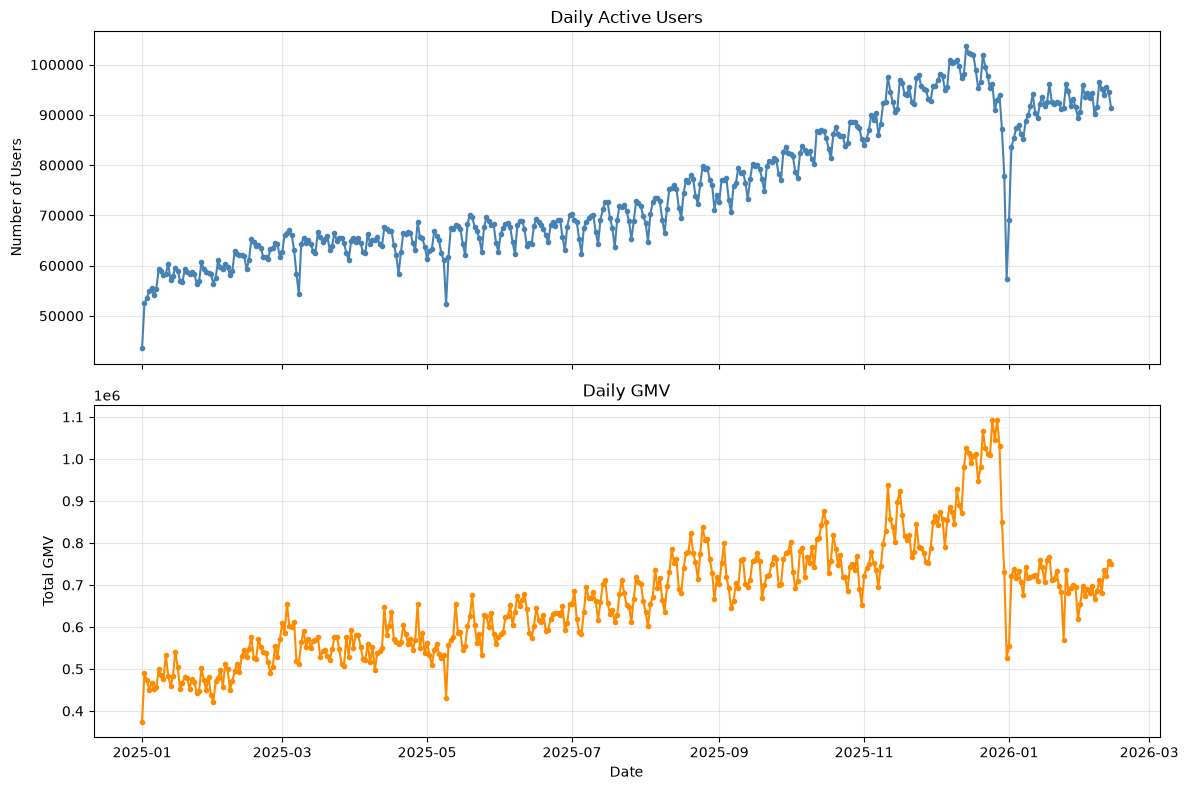

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Active users
axes[0].plot(daily_agg["event_date"], daily_agg["n_users"], marker=".", linestyle="-", color="steelblue")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("Daily Active Users")
axes[0].grid(True, alpha=0.3)

# Total GMV
axes[1].plot(daily_agg["event_date"], daily_agg["gmv_sum"], marker=".", linestyle="-", color="darkorange")
axes[1].set_ylabel("Total GMV")
axes[1].set_title("Daily GMV")
axes[1].grid(True, alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

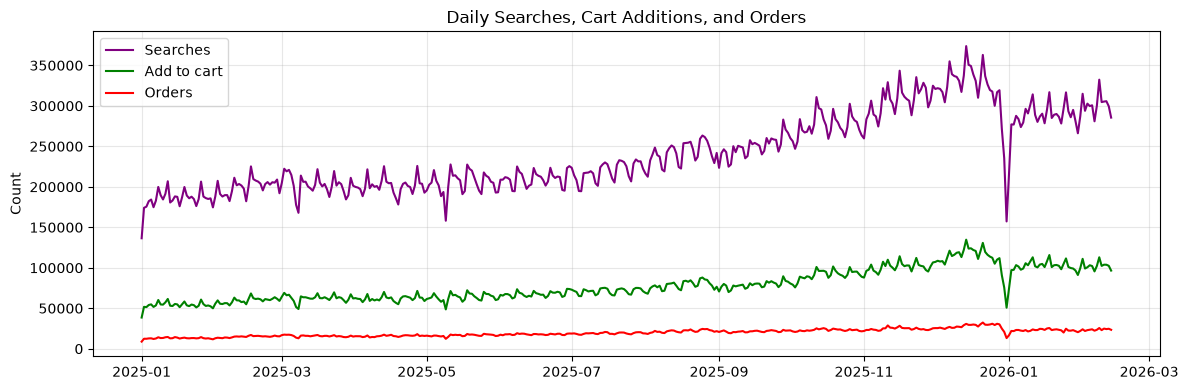

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(daily_agg["event_date"], daily_agg["searches_sum"], label="Searches", color="purple")
plt.plot(daily_agg["event_date"], daily_agg["to_cart_sum"], label="Add to cart", color="green")
plt.plot(daily_agg["event_date"], daily_agg["to_ord_sum"], label="Orders", color="red")
plt.legend()
plt.title("Daily Searches, Cart Additions, and Orders")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Let's prepare some features 

- Not everyone has large RAM machines, especially in mid 2026
- So let's first build time-based features and targets...
- And build them batched by users
- After we're done we can work with extracted data directly as if it was a much simpler regression task

In [8]:
# keep extra features for homework
DEFAULT_AGGS = ["sum", "max", "std", "mean"]
DEFAULT_VALUE_COLS = ["gmv", "searches"]

# and a place to save our stuff
FEATURES_DIR = "data/v2/features"

# and choose a simple path for now
N_FOLDS = 4

# mind your RAM capabilities
# in case of really low-RAM machines mind that data is sorted by user (and by event_date later)
BATCH_SIZE = 50_000

# window = [anchor - start_off, anchor - end_off] (inclusive)
DEFAULT_WINDOWS = [
    ("30d", 29, 0),    # [t-29, t-0]  (includes anchor)
    ("60d", 59, 30),   # [t-59, t-30]
    ("90d", 89, 60),   # [t-89, t-60]
]

output_dir = Path(FEATURES_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

In [9]:
# Build key anchor dates for time-CV windows
def generate_cv_anchor_dates(
    data: pl.DataFrame,
    prediction_horizon_days: int = 30,
    stride_days: int = 14,
    min_history_days: int = 90,
    n_folds: Optional[int] = None,
) -> list[date]:
   
    min_date = data["event_date"].min()
    max_date = data["event_date"].max()

    latest_anchor = max_date - timedelta(days = prediction_horizon_days)
    earliest_anchor = min_date + timedelta(days = min_history_days - 1)

    # sanity check
    if latest_anchor < earliest_anchor:
        raise ValueError(
            f"Not enough data: need >={min_history_days + prediction_horizon_days - 1} days, "
            f"got {(max_date - min_date).days}."
        )

    n_steps = (latest_anchor - earliest_anchor).days // stride_days
    all_anchors = [latest_anchor - timedelta(days=i * stride_days) for i in range(n_steps + 1)]
    all_anchors = sorted(all_anchors)

    if n_folds is not None:
        if n_folds <= 0:
            raise ValueError("n_folds must be a positive integer.")
        return all_anchors[-n_folds:]
    
    return all_anchors

In [10]:
# helper feature recepies
# BYOF yet consider a tokenizer path instead :)
def _window_agg_exprs(
    anchor_val: date,
    windows: list[tuple[str, int, int]],
    value_cols: list[str],
    aggs: list[str],
) -> list[pl.Expr]:
    exprs = []
    for w_name, start_off, end_off in windows:
        w_start = anchor_val - timedelta(days = start_off)
        w_end = anchor_val - timedelta(days = end_off)
        mask = pl.col("event_date").is_between(w_start, w_end)

        for col in value_cols:
            for agg in aggs:
                if agg == "sum":
                    e = pl.when(mask).then(pl.col(col)).otherwise(0.0).sum()
                elif agg == "max":
                    e = pl.when(mask).then(pl.col(col)).otherwise(None).max()
                elif agg == "std":
                    e = pl.when(mask).then(pl.col(col)).otherwise(None).std()
                elif agg == "mean":
                    e = pl.when(mask).then(pl.col(col)).otherwise(None).mean()
                elif agg == "count":
                    e = pl.when(mask).then(1).otherwise(0).sum()
                else:
                    raise ValueError(f"Unknown agg: {agg}")
                exprs.append(e.alias(f"{col}_{agg}_{w_name}"))
    return exprs

In [11]:
# batch-ready features
# you can extract features right away, however it is likely to eat 40GB+ RAM
def generate_features(
    data: pl.DataFrame,
    anchor_dates: list[date],
    user_ids: Optional[list[int]] = None,
    value_cols: list[str] = DEFAULT_VALUE_COLS,
    windows: list[tuple[str, int, int]] = DEFAULT_WINDOWS,
    aggs: list[str] = DEFAULT_AGGS,
) -> pl.DataFrame:
    if user_ids is None:
        user_ids = data["user_id"].unique().sort().to_list()

    max_back = max(w[1] for w in windows)
    min_anchor, max_anchor = min(anchor_dates), max(anchor_dates)

    data_f = data.filter(
        pl.col("user_id").is_in(user_ids)
        & pl.col("event_date").is_between(
            min_anchor - timedelta(days=max_back),
            max_anchor,
        )
    )

    parts = []
    for a in anchor_dates:
        ad = data_f.filter(pl.col("event_date") >= a - timedelta(days=max_back))
        if len(ad) > 0:
            features = (
                ad.group_by("user_id")
                  .agg(_window_agg_exprs(a, windows, value_cols, aggs))
                  .with_columns(anchor_date=pl.lit(a))
            )
            parts.append(features)

    features_df = pl.concat(parts, how="diagonal_relaxed") if parts else pl.DataFrame()
    index_df = (
        pl.DataFrame({"anchor_date": anchor_dates})
        .join(pl.DataFrame({"user_id": user_ids}), how="cross")
    )
    result = index_df.join(features_df, on=["anchor_date", "user_id"], how="left")

    feature_cols = [c for c in result.columns if c not in ["anchor_date", "user_id"]]
    fill_exprs = [pl.col(c).fill_null(0.0) for c in feature_cols]

    
    return result.with_columns(fill_exprs)


In [12]:
# batch-ready target construction
def generate_targets(
    data: pl.DataFrame,
    anchor_dates: list[date],
    user_ids: Optional[list[int]] = None,
    horizon_days: int = 30,
    target_col: str = "gmv",
) -> pl.DataFrame:
    if user_ids is None:
        user_ids = data["user_id"].unique().sort().to_list()

    index_df = (
        pl.DataFrame({"anchor_date": anchor_dates})
        .join(pl.DataFrame({"user_id": user_ids}), how="cross")
    )

    parts = []
    for a in anchor_dates:
        t_start = a + timedelta(days=1)
        t_end   = a + timedelta(days=horizon_days)
        tgt = (
            data.filter(
                pl.col("user_id").is_in(user_ids)
                & pl.col("event_date").is_between(t_start, t_end)
            )
            .group_by("user_id")
            .agg(pl.col(target_col).sum().alias("target"))
            .with_columns(anchor_date=pl.lit(a))
        )
        parts.append(tgt)

    tgt_df = pl.concat(parts, how="diagonal_relaxed") if parts else pl.DataFrame()
    targets = index_df.join(tgt_df, on=["anchor_date", "user_id"], how="left")
    return targets.with_columns(pl.col("target").fill_null(0.0))

In [13]:
# prepare our time anchor structure
anchors_time_folds = generate_cv_anchor_dates(data, n_folds = N_FOLDS)
anchor_end_of_time = data["event_date"].max()

print(f"Time-CV folds   : {len(anchors_time_folds)} | {anchors_time_folds[0]} → "
    f"{anchors_time_folds[-1]} | stride = 14 days")
print(f"Prediction fold : {anchor_end_of_time} → predict [{anchor_end_of_time + timedelta(days = 1)}, "
    f"{anchor_end_of_time + timedelta(days = 30)}]")

Time-CV folds   : 4 | 2025-12-03 → 2026-01-14 | stride = 14 days
Prediction fold : 2026-02-13 → predict [2026-02-14, 2026-03-15]


In [14]:
# prepare for batch extraction
user_ids = data["user_id"].unique().sort().to_list()

n_users   = len(user_ids)
n_batches = (n_users + BATCH_SIZE - 1) // BATCH_SIZE
print(f"\n{n_users} users → {n_batches} batches per fold (batch_size = {BATCH_SIZE})\n")


250000 users → 5 batches per fold (batch_size = 50000)



### Let's roll

In [15]:
# 1. Process CV Folds 

for fold_idx, anchor in enumerate(anchors_time_folds):

    fold_name = f"fold_{fold_idx:02d}"
    fold_dir = output_dir / fold_name
    fold_dir.mkdir(parents=True, exist_ok=True)

    for batch in range(n_batches):
        current_batch = user_ids[batch * BATCH_SIZE : (batch + 1) * BATCH_SIZE]
        features = generate_features(data, [anchor], user_ids = current_batch)
        targets = generate_targets(data, [anchor], user_ids = current_batch,
                                horizon_days = 30)
            
        out_df = features.join(targets, on=["anchor_date", "user_id"], how="left")
        out_df = out_df.with_columns(pl.col("target").fill_null(0.0))
        out_df.write_parquet(fold_dir / f"batch_{batch:04d}.parquet")
            
    print(f"  Processed {fold_name} (anchor: {anchor})")

  Processed fold_00 (anchor: 2025-12-03)
  Processed fold_01 (anchor: 2025-12-17)
  Processed fold_02 (anchor: 2025-12-31)
  Processed fold_03 (anchor: 2026-01-14)


In [16]:
# 2. Process Final Prediction Fold

fold_dir = output_dir / "fold_end"
fold_dir.mkdir(parents=True, exist_ok=True)

for batch in range(n_batches):
    current_batch = user_ids[batch * BATCH_SIZE : (batch + 1) * BATCH_SIZE]
    feats = generate_features(data, [anchor_end_of_time], user_ids = current_batch)
    out_df = feats.with_columns(pl.lit(None).cast(pl.Float64).alias("target"))
    out_df.write_parquet(fold_dir / f"batch_{batch:04d}.parquet")
        
print(f"  Processed fold_last (anchor: {anchor_end_of_time})")

  Processed fold_last (anchor: 2026-02-13)


### Now on to ML

- Let's check what we are up for
- After that let's decide our next best plan of action

In [17]:
# safe clipped log1p RMSLE
def rmsle(y_true, y_pred):
    log_true = np.log1p(np.clip(y_true, 0, None))
    log_pred = np.log1p(np.clip(y_pred, 0, None))
    return np.sqrt(mean_squared_error(log_true, log_pred))

# small helper to read our processed feature folds
def read_fold(output_dir: str | Path, fold_name: str):
    pattern = str(Path(output_dir) / fold_name / "batch_*.parquet")
    return pl.read_parquet(pattern)

In [18]:
folds = []
for fold_idx, anchor in enumerate(anchors_time_folds):
    fold_name = f"fold_{fold_idx:02d}"
    fold_df = read_fold(FEATURES_DIR, fold_name)
    folds.append(fold_df)

### Some catboosting maybe?

- Maybe with Tweedie due to heavy zero-inflation?
- Maybe some extra features as well, as one could have guessed gmv_sum_30/60/90 are ther most important?
- ...
- Nah, let's roll with simple autyoregression

In [19]:
# this is our last train data fold, with fair target 
folds[3].head(5)

anchor_date,user_id,gmv_sum_30d,gmv_max_30d,gmv_std_30d,gmv_mean_30d,searches_sum_30d,searches_max_30d,searches_std_30d,searches_mean_30d,gmv_sum_60d,gmv_max_60d,gmv_std_60d,gmv_mean_60d,searches_sum_60d,searches_max_60d,searches_std_60d,searches_mean_60d,gmv_sum_90d,gmv_max_90d,gmv_std_90d,gmv_mean_90d,searches_sum_90d,searches_max_90d,searches_std_90d,searches_mean_90d,target
date,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-01-14,2,16.315287,16.315287,8.157644,4.078822,13.0,5.0,1.5,3.25,0.0,0.0,0.0,0.0,9.0,9.0,0.0,9.0,0.0,0.0,0.0,0.0,7.0,5.0,2.309401,2.333333,0.0
2026-01-14,7,288.283114,257.468616,68.67056,20.591651,42.0,17.0,4.402796,3.0,181.124603,70.065728,27.937945,15.093717,32.0,5.0,1.61433,2.666667,28.615134,16.246318,7.955584,5.723027,7.0,2.0,0.547723,1.4,486.96535
2026-01-14,15,2264.174894,2237.575574,620.005196,174.1673,26.0,14.0,3.719319,2.0,133.692441,133.692441,42.277262,13.369244,8.0,2.0,0.788811,0.8,0.0,0.0,0.0,0.0,4.0,4.0,0.0,4.0,0.0
2026-01-14,18,584.802181,250.101994,64.463223,30.779062,55.0,10.0,3.413938,2.894737,25.739683,25.739683,6.645958,1.715979,38.0,23.0,5.717975,2.533333,227.428092,168.281835,51.870829,22.742809,17.0,7.0,1.946507,1.7,276.0091
2026-01-14,23,0.0,0.0,0.0,0.0,10.0,5.0,1.527525,3.333333,0.0,0.0,0.0,0.0,5.0,4.0,2.12132,2.5,0.0,0.0,0.0,0.0,18.0,9.0,3.224903,3.0,0.0


In [20]:
# let's use this target as the basis fort our submit
submit_naive = folds[3].select(["user_id", "target"])
submit_naive.columns = ["user_id", "predict"]
print(submit_naive.shape)

(250000, 2)


In [21]:
# Now quickly save it before any ML happens and find ourselves on leaderboard!
submit_naive.write_csv("data/sample_naive_submit.csv")